In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText


In [21]:
# ----------------------------
# Load
# ----------------------------
df = pd.read_csv("../results/NEON-CPU.csv")

# Full strategy name
df["strategy_full"] = (
    df["strategy"]
    + " ("
    + df["julia_or_neon"]
    + ")"
)
df = df[df["cells"] == 64000000]
# ----------------------------
# Convert time -> milliseconds
# ----------------------------
df["ms_mean"] = df["time_us"] / 1e3

# Effective bandwidth [GB/s]
# nnz * 24 bytes / runtime
df["bandwidth"] = df["nnz"] * 24  / (df["ms_mean"] * 1000000) 

# Equivalent:
# df["bandwidth"] = df["nnz"] * 24 / (df["time_us"] / 1e6)

# ----------------------------
# Aggregate repetitions
# ----------------------------
agg = (
    df.groupby(
        [
            "strategy_full",
            "threads",
            "node",
            "executor",
        ],
        as_index=False,
    )
    .agg(
        bandwidth=("bandwidth", "median")
    )
)

# ----------------------------
# Normalize against threads=1
# per strategy / node
# ----------------------------
baseline = (
    agg[agg["threads"] == 1]
    [["strategy_full", "node", "executor", "bandwidth"]]
    .rename(
        columns={
            "bandwidth": "bw_1"
        }
    )
)

# ----------------------------
# Normalize against the serial implementation
# per node
# ----------------------------
serial_baseline_strategy = "Face-Based (JuNe)"
serial_baseline = (
    agg[
        (agg["threads"] == 1)
        & (agg["strategy_full"] == serial_baseline_strategy)
    ]
    [["node", "executor", "bandwidth"]]
    .rename(
        columns={
            "bandwidth": "bw_serial"
        }
    )
)

plot_df = (
    agg.merge(
        baseline,
        on=[
            "strategy_full",
            "node",
            "executor",
        ],
    )
    .merge(
        serial_baseline,
        on=[
            "node",
            "executor",
        ],
    )
)

plot_df["speedup"] = (
    plot_df["bandwidth"]
    / plot_df["bw_1"]
)
plot_df["speedup_vs_serial_bandwidth"] = (
    plot_df["bandwidth"]
    / plot_df["bw_serial"]
)

# plot_df = plot_df[
#     [
#         "strategy_full",
#         "threads",
#         "node",
#         "executor",
#         "bandwidth",
#         "bw_1",
#         "bw_serial",
#         "speedup",
#         "speedup_vs_serial_bandwidth",
#     ]
# ]


In [19]:
plot_df

,strategy_full,threads,node,executor,bandwidth,bw_1,bw_serial,speedup,speedup_vs_serial_bandwidth
0,Cell-Based (JuNe),1,gpu-nvidia-h100,CPU,0.118063,0.118063,0.153447,1.000000,0.769408
1,Cell-Based (JuNe),1,gpu-nvidia-h200,CPU,0.386902,0.386902,0.400000,1.000000,0.967254
2,Cell-Based (JuNe),2,gpu-nvidia-h100,CPU,0.320668,0.118063,0.153447,2.716075,2.089770
3,Cell-Based (JuNe),2,gpu-nvidia-h200,CPU,0.701370,0.386902,0.400000,1.812785,1.753425
4,Cell-Based (JuNe),4,gpu-nvidia-h100,CPU,0.351487,0.118063,0.153447,2.977117,2.290618
...,...,...,...,...,...,...,...,...,...
123,Global Face-Based (NeoN),32,gpu-nvidia-h200,CPU,0.898246,0.685714,0.400000,1.309942,2.245614
124,Global Face-Based (NeoN),64,gpu-nvidia-h100,CPU,0.526027,0.381141,0.153447,1.380137,3.428082
125,Global Face-Based (NeoN),64,gpu-nvidia-h200,CPU,0.640000,0.685714,0.400000,0.933333,1.600000
126,Global Face-Based (NeoN),128,gpu-nvidia-h100,CPU,0.190571,0.381141,0.153447,0.500000,1.241935


labels: ['Cell-Based (JuNe)', 'Cell-Based (NeoN)', 'Face-Based (JuNe)', 'Face-Based (NeoN)', 'Fused Cell-Based (NeoN)', 'Fused Face-Based (NeoN)', 'Global Face-Based (JuNe)', 'Global Face-Based (NeoN)', 'Ideal']


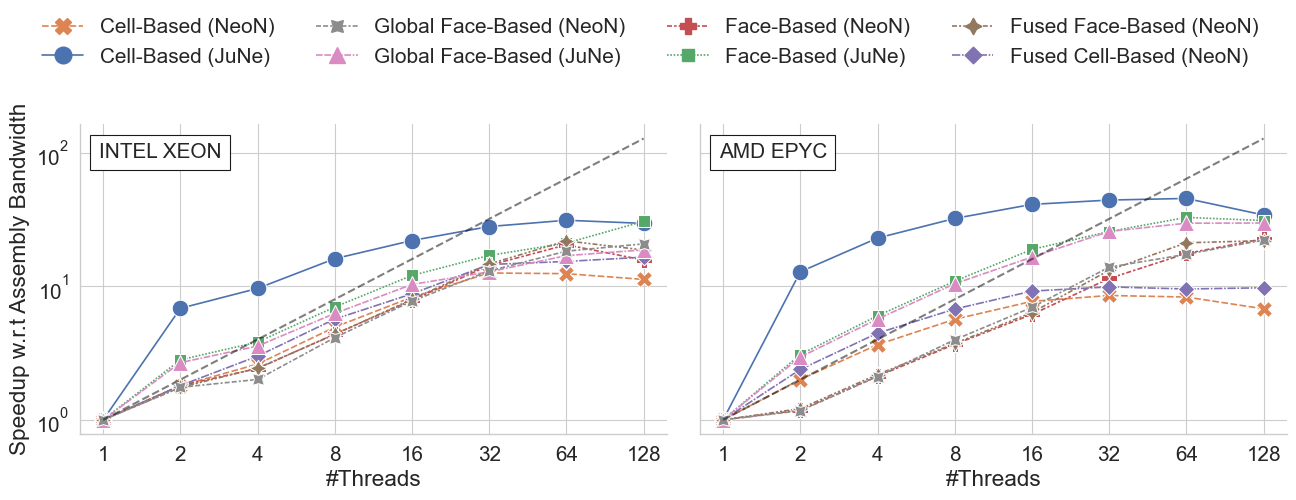

In [22]:

# ----------------------------
# Plot
# ----------------------------
sns.set_theme(rc={'figure.figsize':(20, 12)})
sns.set_style("whitegrid")
sns.color_palette("deep", 8)

nodes = sorted(plot_df["node"].unique())
threads = sorted(plot_df["threads"].unique())
thread_positions = {thread: pos for pos, thread in enumerate(threads)}
speedup_plot_df = plot_df.assign(
    thread_pos=plot_df["threads"].map(thread_positions)
)

# for ax, node in zip(axes, nodes):
with sns.plotting_context("paper", font_scale=1.7):
    p = sns.relplot(
        # data=df[(df["threads"]==128) ],
        data=speedup_plot_df,
        x="thread_pos",
        y="speedup",
        kind="line",
        col="node",
        col_order=["gpu-nvidia-h100", "gpu-nvidia-h200"],
        hue="strategy_full",
        style="strategy_full",
        markersize=12,
        markers=True
    )

    # Ideal scaling
    thread_x = list(range(len(threads)))
    for ax in p.axes.flat:
        ax.plot(
            thread_x,
            threads,
            "--",
            color="black",
            alpha=0.5,
            linewidth=1.5,
            label="Ideal",
        )

    p.set(
        yscale="log",
        xlabel="#Threads",
        ylabel="Speedup w.r.t Assembly Bandwidth",
    )
    for ax in p.axes.flat:
        ax.set_xticks(thread_x)
        ax.set_xticklabels(threads)
        ax.set_xlim(thread_x[0] - 0.3, thread_x[-1] + 0.3)

    desired_order = [
        "Cell-Based (NeoN)",
        "Cell-Based (JuNe)",
        "Global Face-Based (NeoN)",
        "Global Face-Based (JuNe)",
        "Face-Based (NeoN)",
        "Face-Based (JuNe)",
        "Fused Face-Based (NeoN)",
        "Fused Cell-Based (NeoN)"
    ]

    handles, labels = p.axes.flat[0].get_legend_handles_labels()
    if p._legend is not None:
        p._legend.remove()
        p._legend = None
    print(f"labels: {labels}")
    by_label = dict(zip(labels, handles))

    ordered_labels = [label for label in desired_order if label in by_label]
    ordered_handles = [by_label[label] for label in ordered_labels]
    
    at = AnchoredText(
        "INTEL XEON",
        loc="upper left",
        # bbox_to_anchor=(0.975, 0.92),
        bbox_transform=p.axes.flat[0].transAxes,
        frameon=True,
        prop={"size": plt.rcParams["legend.fontsize"]},
    )
    p.axes.flat[0].add_artist(at)  
    at = AnchoredText(
        "AMD EPYC",
        loc="upper left",
        # bbox_to_anchor=(0.975, 0.92),
        bbox_transform=p.axes.flat[1].transAxes,
        frameon=True,
        prop={"size": plt.rcParams["legend.fontsize"]},
    )
    p.axes.flat[1].add_artist(at)    
    p.set_titles("")

    p.fig.legend(
        ordered_handles,
        ordered_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.03),
        ncol=4,
        # title="Fused Strategy",
        frameon=False,
    )
    p.fig.subplots_adjust(
        left=0.07,
        right=0.98,
        # bottom=0.18,
        top=0.78,
        # wspace=0.1,
    )
plt.savefig("cpu-speedup-bandwidth.svg")

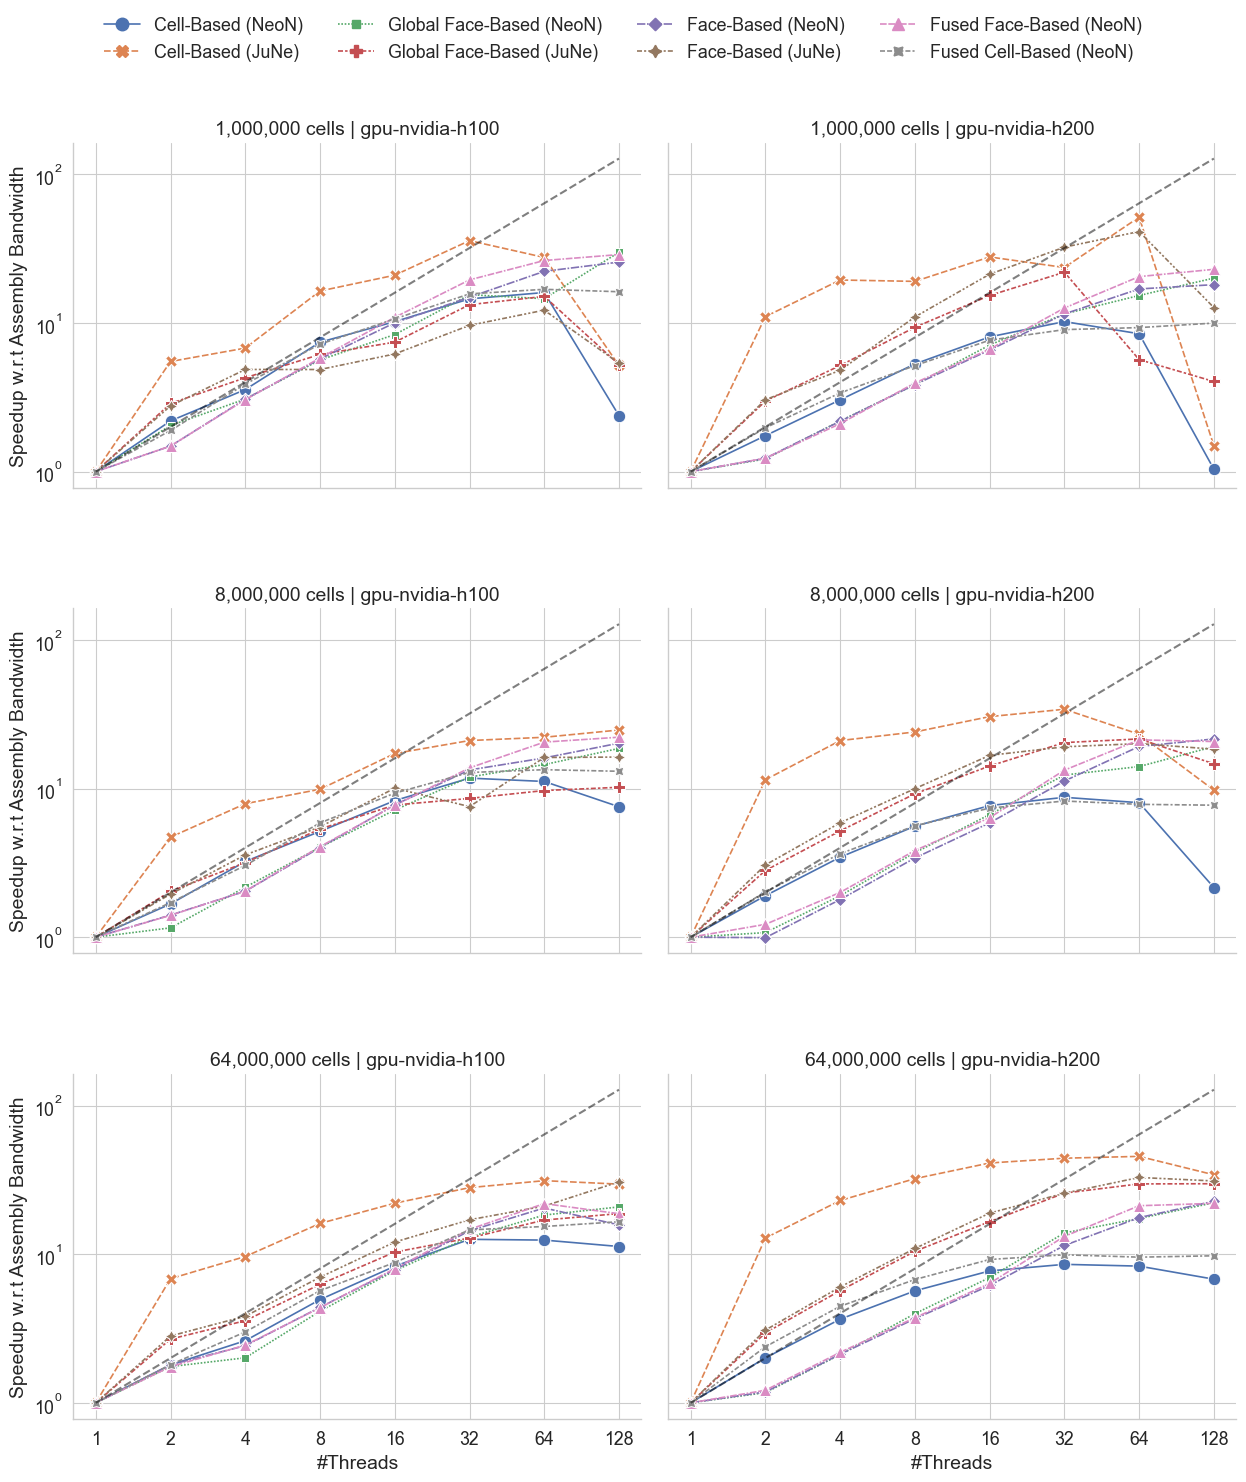

In [26]:
# ----------------------------
# Speedup per problem size
# ----------------------------
sns.set_theme(rc={"figure.figsize": (20, 14)})
sns.set_style("whitegrid")
sns.color_palette("deep", 8)

cell_speedup_source_df = pd.read_csv("../results/NEON-CPU.csv")
cell_speedup_source_df["strategy_full"] = (
    cell_speedup_source_df["strategy"]
    + " ("
    + cell_speedup_source_df["julia_or_neon"]
    + ")"
)
cell_speedup_source_df["ms_mean"] = cell_speedup_source_df["time_us"] / 1e3
cell_speedup_source_df["bandwidth"] = (
    cell_speedup_source_df["nnz"]
    * 24
    / (cell_speedup_source_df["ms_mean"] * 1_000_000)
)

cell_agg = (
    cell_speedup_source_df.groupby(
        ["strategy_full", "threads", "node", "executor", "cells"],
        as_index=False,
    )
    .agg(bandwidth=("bandwidth", "median"))
)

cell_baseline = (
    cell_agg[cell_agg["threads"] == 1]
    [["strategy_full", "node", "executor", "cells", "bandwidth"]]
    .rename(columns={"bandwidth": "bw_1"})
)

cell_speedup_plot_df = cell_agg.merge(
    cell_baseline,
    on=["strategy_full", "node", "executor", "cells"],
)
cell_speedup_plot_df["speedup"] = (
    cell_speedup_plot_df["bandwidth"]
    / cell_speedup_plot_df["bw_1"]
)

selected_cells = [1_000_000, 8_000_000, 64_000_000]
cell_speedup_plot_df = cell_speedup_plot_df[
    cell_speedup_plot_df["cells"].isin(selected_cells)
].copy()
cell_speedup_plot_df["cells_label"] = cell_speedup_plot_df["cells"].map(
    lambda value: f"{value:,} cells"
)

threads = sorted(cell_speedup_plot_df["threads"].unique())
thread_positions = {thread: pos for pos, thread in enumerate(threads)}
thread_x = list(range(len(threads)))
cell_speedup_plot_df["thread_pos"] = cell_speedup_plot_df["threads"].map(
    thread_positions
)

cell_order = [f"{cells:,} cells" for cells in selected_cells]
col_order = ["gpu-nvidia-h100", "gpu-nvidia-h200"]
desired_order = [
    "Cell-Based (NeoN)",
    "Cell-Based (JuNe)",
    "Global Face-Based (NeoN)",
    "Global Face-Based (JuNe)",
    "Face-Based (NeoN)",
    "Face-Based (JuNe)",
    "Fused Face-Based (NeoN)",
    "Fused Cell-Based (NeoN)",
]

with sns.plotting_context("paper", font_scale=1.45):
    p = sns.relplot(
        data=cell_speedup_plot_df,
        x="thread_pos",
        y="speedup",
        kind="line",
        row="cells_label",
        row_order=cell_order,
        col="node",
        col_order=col_order,
        hue="strategy_full",
        hue_order=desired_order,
        style="strategy_full",
        style_order=desired_order,
        markers=True,
        markersize=9,
        errorbar=None,
    )

    for ax in p.axes.flat:
        ax.plot(
            thread_x,
            threads,
            "--",
            color="black",
            alpha=0.5,
            linewidth=1.5,
            label="Ideal",
        )
        ax.set_xticks(thread_x)
        ax.set_xticklabels(threads)
        ax.set_xlim(thread_x[0] - 0.3, thread_x[-1] + 0.3)

    p.set(
        yscale="log",
        xlabel="#Threads",
        ylabel="Speedup w.r.t Assembly Bandwidth",
    )
    p.set_titles(col_template="{col_name}", row_template="{row_name}")

    handles, labels = p.axes.flat[0].get_legend_handles_labels()
    if p._legend is not None:
        p._legend.remove()
        p._legend = None

    by_label = dict(zip(labels, handles))
    ordered_labels = [label for label in desired_order if label in by_label]
    ordered_handles = [by_label[label] for label in ordered_labels]

    p.fig.legend(
        ordered_handles,
        ordered_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.995),
        ncol=4,
        frameon=False,
    )
    p.fig.subplots_adjust(left=0.07, right=0.98, top=0.9, hspace=0.35)

plt.savefig("cpu-speedup-bandwidth-by-cells.svg", bbox_inches="tight")


labels: ['Fused Cell-Based (NeoN)', 'Cell-Based (NeoN)', 'Global Face-Based (NeoN)', 'Face-Based (JuNe)', 'Cell-Based (JuNe)', 'Global Face-Based (JuNe)', 'Fused Face-Based (NeoN)', 'Face-Based (NeoN)']


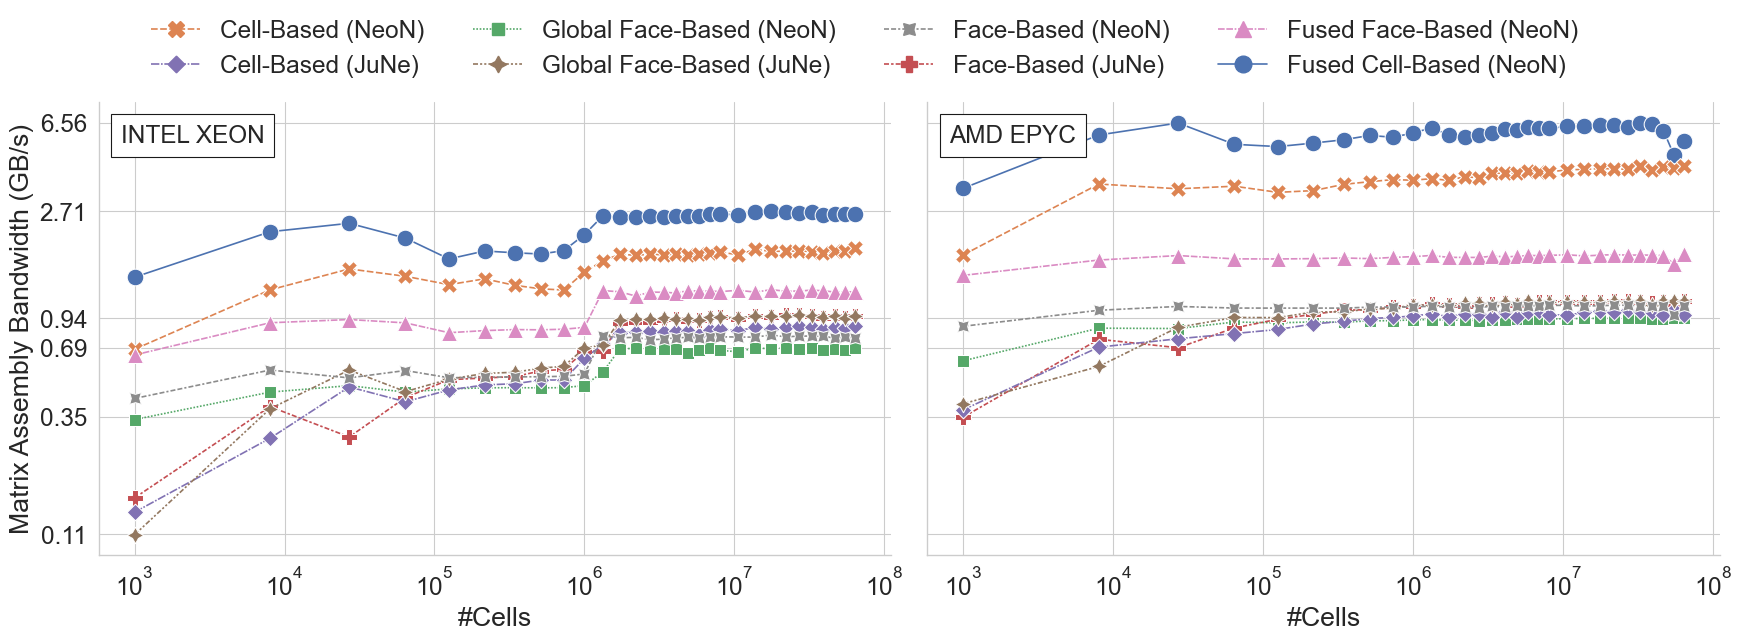

In [75]:
# ----------------------------
# Plot
# ----------------------------
sns.set_theme(rc={'figure.figsize':(20, 12)})
sns.set_style("whitegrid")
sns.color_palette("deep", 8)

bandwidth_source_df = pd.read_csv("../results/NEON-CPU.csv")
bandwidth_source_df["strategy_full"] = (
    bandwidth_source_df["strategy"]
    + " ("
    + bandwidth_source_df["julia_or_neon"]
    + ")"
)
bandwidth_source_df["ms_mean"] = bandwidth_source_df["time_us"] / 1e3
bandwidth_source_df["bandwidth"] = bandwidth_source_df["nnz"] * 24 / (bandwidth_source_df["ms_mean"] * 1000000)
bandwidth_plot_df = bandwidth_source_df[bandwidth_source_df["threads"] == 1].copy()
nodes = sorted(bandwidth_plot_df["node"].unique())

# for ax, node in zip(axes, nodes):
with sns.plotting_context("paper", font_scale=2):
    p = sns.relplot(
        data=bandwidth_plot_df,
        x="cells",
        y="bandwidth",
        kind="line",
        col="node",
        col_order=["gpu-nvidia-h100", "gpu-nvidia-h200"],
        hue="strategy_full",
        style="strategy_full",
        err_style=None,
        markersize=12,
        height=7,
        markers=True
    )

    # Ideal scaling
    threads = sorted(
        bandwidth_source_df["threads"].unique()
    )

    p.set(
        yscale="log",
        xscale="log",
        xlabel="#Cells",
        ylabel="Matrix Assembly Bandwidth (GB/s)",
    )
    ytick_strategies = [
        "Fused Cell-Based (NeoN)",
        "Global Face-Based (NeoN)",
    ]
    line_bandwidth = bandwidth_plot_df.groupby(
        ["node", "strategy_full", "cells"],
        as_index=False,
    )["bandwidth"].mean()
    peak_yticks = line_bandwidth[
        line_bandwidth["strategy_full"].isin(ytick_strategies)
    ].groupby(["node", "strategy_full"])["bandwidth"].max().to_numpy()
    min_yticks = line_bandwidth.groupby("node")["bandwidth"].min().to_numpy()
    extra_yticks = np.concatenate([peak_yticks, min_yticks])
    for ax in p.axes.flat:
        ymin, ymax = ax.get_ylim()
        custom_yticks = [round(float(tick), 3) for tick in extra_yticks if ymin <= tick <= ymax]
        ytick_values = sorted(set(custom_yticks))
        ax.set_yticks(ytick_values)
        ax.set_yticklabels([
            f"{tick:.2f}"
            for tick in ytick_values
        ])
    p.axes.flat[0].tick_params(axis="y", which="both", labelleft=True)
    p.axes.flat[1].tick_params(axis="y", which="both", labelleft=False)

    desired_order = [
        "Cell-Based (NeoN)",
        "Cell-Based (JuNe)",
        "Global Face-Based (NeoN)",
        "Global Face-Based (JuNe)",
        "Face-Based (NeoN)",
        "Face-Based (JuNe)",
        "Fused Face-Based (NeoN)",
        "Fused Cell-Based (NeoN)"
    ]
    handles, labels = p.axes.flat[0].get_legend_handles_labels()
    if p._legend is not None:
        p._legend.remove()
        p._legend = None
    print(f"labels: {labels}")
    by_label = dict(zip(labels, handles))

    ordered_labels = [label for label in desired_order if label in by_label]
    ordered_handles = [by_label[label] for label in ordered_labels]
    
    at = AnchoredText(
        "INTEL XEON",
        loc="upper left",
        # bbox_to_anchor=(0.975, 0.92),
        bbox_transform=p.axes.flat[0].transAxes,
        frameon=True,
        prop={"size": plt.rcParams["legend.fontsize"]},
    )
    p.axes.flat[0].add_artist(at)  
    at = AnchoredText(
        "AMD EPYC",
        loc="upper left",
        # bbox_to_anchor=(0.975, 0.92),
        bbox_transform=p.axes.flat[1].transAxes,
        frameon=True,
        prop={"size": plt.rcParams["legend.fontsize"]},
    )
    p.axes.flat[1].add_artist(at)    
    p.set_titles("")

    p.fig.legend(
        ordered_handles,
        ordered_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.93),
        ncol=4,
        # title="Fused Strategy",
        frameon=False,
    )
    p.fig.subplots_adjust(
        left=0.07,
        right=0.98,
        # bottom=0.18,
        top=0.78,
        # wspace=0.1,
    )

plt.savefig("cpu-bandwidth-1.svg")


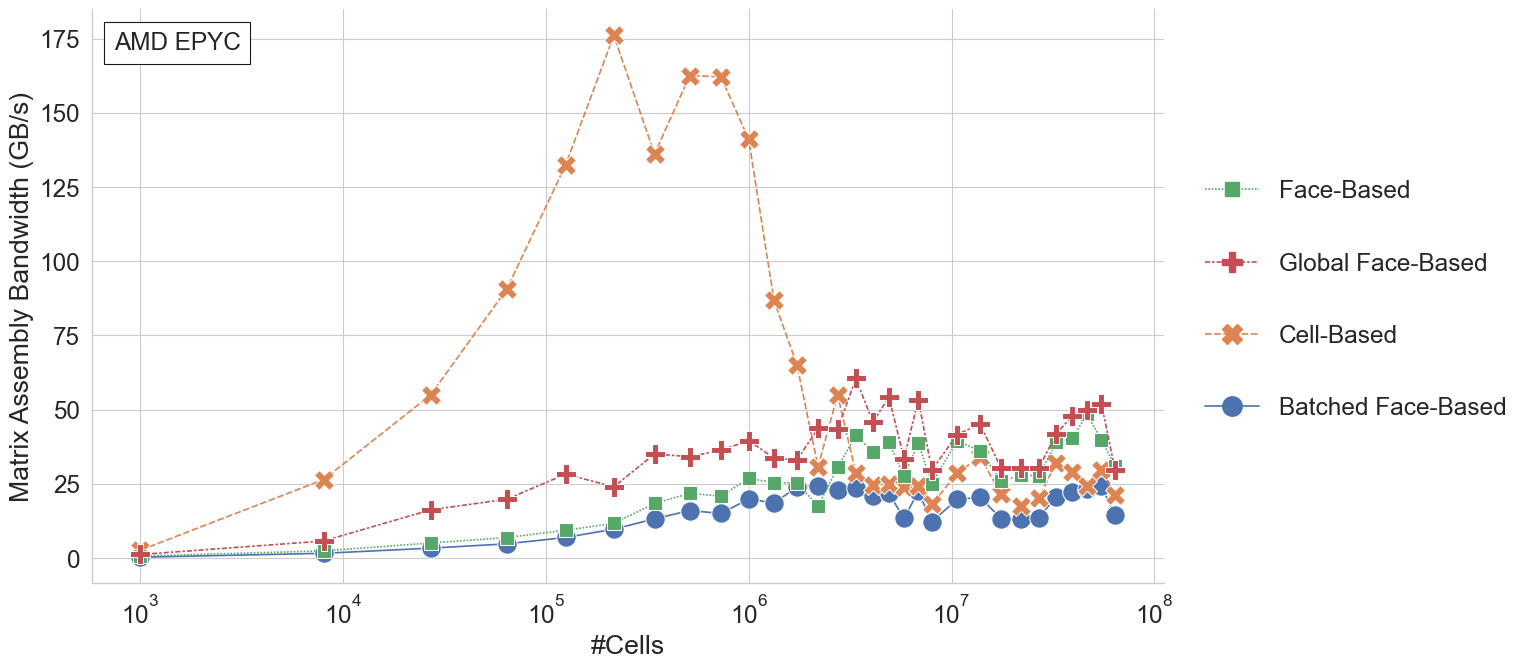

In [96]:
# Polyester bandwidth at 128 threads on AMD
sns.set_style("whitegrid")
polyester_figure_size = (16, 7)
polyester_plot_bounds = {
    "left": 0.06,
    "right": 0.73,
    "bottom": 0.14,
    "top": 0.96,
}
polyester_legend_x = 0.75
polyester_legend_y_limits = (0.7, 0.39)

polyester_source_df = pd.read_csv(
    "../variants/variations_cpu_polyester_pinnedthreads.csv",
    skip_blank_lines=True,
)
polyester_source_df["cells"] = (
    polyester_source_df["case_long"].str.rsplit("-", n=1).str[-1].astype(int)
)
polyester_nnz_df = (
    pd.read_csv("../results/NEON-CPU.csv")[["cells", "nnz"]]
    .drop_duplicates("cells")
)
polyester_source_df = polyester_source_df.merge(
    polyester_nnz_df,
    on="cells",
    how="left",
    validate="many_to_one",
)
polyester_source_df["bandwidth"] = (
    polyester_source_df["nnz"]
    * 8
    / (polyester_source_df["time_mean_ms"] * 1_000_000)
)
polyester_strategy_names = {
    "batchedFace": "Batched Face-Based",
    "cellBased": "Cell-Based",
    "faceBased": "Face-Based",
    "globalFaceBased": "Global Face-Based",
}
polyester_source_df["strategy_display"] = polyester_source_df["strategy"].map(
    polyester_strategy_names
)
polyester_plot_df = polyester_source_df[
    (polyester_source_df["Threads"] == 128)
    & (polyester_source_df["variant"] == "Fused")
    & (polyester_source_df["node"] == "H200")
].copy()
polyester_strategy_order = sorted(polyester_plot_df["strategy_display"].unique())
polyester_palette = dict(
    zip(
        polyester_strategy_order,
        sns.color_palette("deep", n_colors=len(polyester_strategy_order)),
    )
)
with sns.plotting_context("paper", font_scale=2):
    polyester_plot = sns.relplot(
        data=polyester_plot_df,
        x="cells",
        y="bandwidth",
        kind="line",
        hue="strategy_display",
        style="strategy_display",
        hue_order=polyester_strategy_order,
        style_order=polyester_strategy_order,
        palette=polyester_palette,
        err_style=None,
        markersize=14,
        markers=True,
        height=polyester_figure_size[1],
        aspect=polyester_figure_size[0] / polyester_figure_size[1],
    )
    polyester_plot.fig.set_size_inches(*polyester_figure_size, forward=True)
    polyester_plot.set(
        xscale="log",
        xlabel="#Cells",
        ylabel="Matrix Assembly Bandwidth (GB/s)",
    )
    polyester_plot.axes.flat[0].tick_params(
        axis="y", which="both", labelleft=True
    )
    polyester_line_bandwidth = polyester_plot_df.groupby(
        ["strategy_display", "cells"],
        as_index=False,
    )["bandwidth"].mean()
    polyester_legend_order = (
        polyester_line_bandwidth.sort_values("cells")
        .groupby("strategy_display")["bandwidth"]
        .last()
        .sort_values(ascending=False)
        .index.tolist()
    )
    polyester_handles, polyester_labels = (
        polyester_plot.axes.flat[0].get_legend_handles_labels()
    )
    if polyester_plot._legend is not None:
        polyester_plot._legend.remove()
        polyester_plot._legend = None
    polyester_by_label = dict(zip(polyester_labels, polyester_handles))
    polyester_ordered_handles = [
        polyester_by_label[label] for label in polyester_legend_order
    ]

    polyester_plot.axes.flat[0].add_artist(
        AnchoredText(
            "AMD EPYC",
            loc="upper left",
            bbox_transform=polyester_plot.axes.flat[0].transAxes,
            frameon=True,
            prop={"size": plt.rcParams["legend.fontsize"]},
        )
    )
    polyester_plot.set_titles("")

    polyester_legend_y_positions = np.linspace(
        *polyester_legend_y_limits,
        len(polyester_legend_order),
    )
    for handle, label, legend_y in zip(
        polyester_ordered_handles,
        polyester_legend_order,
        polyester_legend_y_positions,
    ):
        polyester_plot.fig.legend(
            [handle],
            [label],
            loc="center left",
            bbox_to_anchor=(polyester_legend_x, float(legend_y)),
            handlelength=2.2,
            borderaxespad=0,
            frameon=False,
        )
    polyester_plot.fig.subplots_adjust(**polyester_plot_bounds)

plt.savefig("cpu-bandwidth-128-polyester-amd.svg")


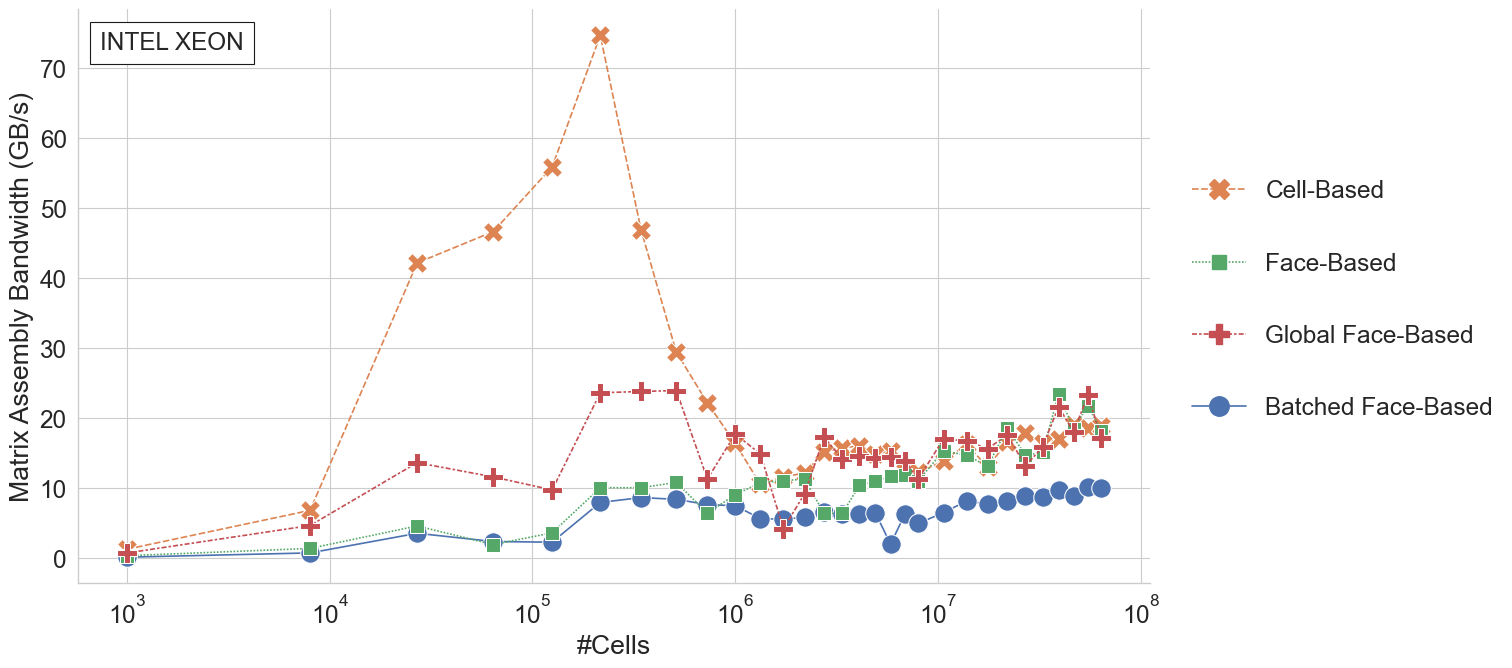

In [ ]:
# Polyester bandwidth at 128 threads on AMD
sns.set_style("whitegrid")
polyester_figure_size = (16, 7)
polyester_plot_bounds = {
    "left": 0.06,
    "right": 0.73,
    "bottom": 0.14,
    "top": 0.96,
}
polyester_legend_x = 0.75
polyester_legend_y_limits = (0.7, 0.39)

polyester_source_df = pd.read_csv(
    "../variants/variations_cpu_polyester_pinnedthreads.csv",
    skip_blank_lines=True,
)
polyester_source_df["cells"] = (
    polyester_source_df["case_long"].str.rsplit("-", n=1).str[-1].astype(int)
)
polyester_nnz_df = (
    pd.read_csv("../results/NEON-CPU.csv")[["cells", "nnz"]]
    .drop_duplicates("cells")
)
polyester_source_df = polyester_source_df.merge(
    polyester_nnz_df,
    on="cells",
    how="left",
    validate="many_to_one",
)
polyester_source_df["bandwidth"] = (
    polyester_source_df["nnz"]
    * 8
    / (polyester_source_df["time_mean_ms"] * 1_000_000)
)
polyester_strategy_names = {
    "batchedFace": "Batched Face-Based",
    "cellBased": "Cell-Based",
    "faceBased": "Face-Based",
    "globalFaceBased": "Global Face-Based",
}
polyester_source_df["strategy_display"] = polyester_source_df["strategy"].map(
    polyester_strategy_names
)
polyester_plot_df = polyester_source_df[
    (polyester_source_df["Threads"] == 128)
    & (polyester_source_df["variant"] == "Fused")
    & (polyester_source_df["node"] == "H100")
].copy()
polyester_strategy_order = sorted(polyester_plot_df["strategy_display"].unique())
polyester_palette = dict(
    zip(
        polyester_strategy_order,
        sns.color_palette("deep", n_colors=len(polyester_strategy_order)),
    )
)
with sns.plotting_context("paper", font_scale=2):
    polyester_plot = sns.relplot(
        data=polyester_plot_df,
        x="cells",
        y="bandwidth",
        kind="line",
        hue="strategy_display",
        style="strategy_display",
        hue_order=polyester_strategy_order,
        style_order=polyester_strategy_order,
        palette=polyester_palette,
        err_style=None,
        markersize=14,
        markers=True,
        height=polyester_figure_size[1],
        aspect=polyester_figure_size[0] / polyester_figure_size[1],
    )
    polyester_plot.fig.set_size_inches(*polyester_figure_size, forward=True)
    polyester_plot.set(
        xscale="log",
        xlabel="#Cells",
        ylabel="Matrix Assembly Bandwidth (GB/s)",
    )
    polyester_plot.axes.flat[0].tick_params(
        axis="y", which="both", labelleft=True
    )
    polyester_line_bandwidth = polyester_plot_df.groupby(
        ["strategy_display", "cells"],
        as_index=False,
    )["bandwidth"].mean()
    polyester_legend_order = (
        polyester_line_bandwidth.sort_values("cells")
        .groupby("strategy_display")["bandwidth"]
        .last()
        .sort_values(ascending=False)
        .index.tolist()
    )
    polyester_handles, polyester_labels = (
        polyester_plot.axes.flat[0].get_legend_handles_labels()
    )
    if polyester_plot._legend is not None:
        polyester_plot._legend.remove()
        polyester_plot._legend = None
    polyester_by_label = dict(zip(polyester_labels, polyester_handles))
    polyester_ordered_handles = [
        polyester_by_label[label] for label in polyester_legend_order
    ]

    polyester_plot.axes.flat[0].add_artist(
        AnchoredText(
            "INTEL XEON",
            loc="upper left",
            bbox_transform=polyester_plot.axes.flat[0].transAxes,
            frameon=True,
            prop={"size": plt.rcParams["legend.fontsize"]},
        )
    )
    polyester_plot.set_titles("")

    polyester_legend_y_positions = np.linspace(
        *polyester_legend_y_limits,
        len(polyester_legend_order),
    )
    for handle, label, legend_y in zip(
        polyester_ordered_handles,
        polyester_legend_order,
        polyester_legend_y_positions,
    ):
        polyester_plot.fig.legend(
            [handle],
            [label],
            loc="center left",
            bbox_to_anchor=(polyester_legend_x, float(legend_y)),
            handlelength=2.2,
            borderaxespad=0,
            frameon=False,
        )
    polyester_plot.fig.subplots_adjust(**polyester_plot_bounds)

plt.savefig("cpu-bandwidth-128-polyester-intel.svg")


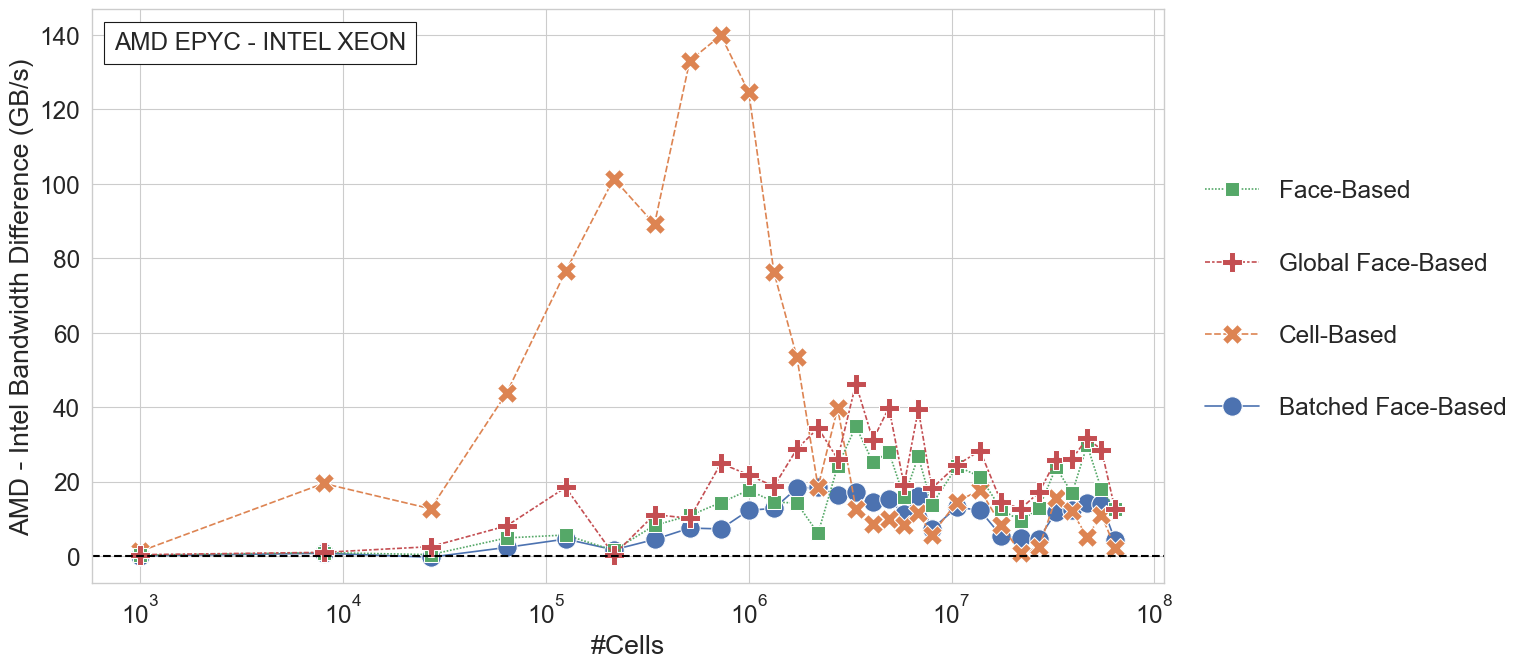

In [92]:
# UPDATE THIS
# AMD - Intel bandwidth difference at 128 threads
amd_bandwidth_128 = (
    polyester_source_df[
        (polyester_source_df["Threads"] == 128)
        & (polyester_source_df["variant"] == "Fused")
        & (polyester_source_df["node"] == "H200")
    ]
    .groupby(["strategy_display", "cells"], as_index=False)["bandwidth"]
    .mean()
    .rename(columns={"bandwidth": "bandwidth_amd"})
)
intel_bandwidth_128 = (
    polyester_source_df[
        (polyester_source_df["Threads"] == 128)
        & (polyester_source_df["variant"] == "Fused")
        & (polyester_source_df["node"] == "H100")
    ]
    .groupby(["strategy_display", "cells"], as_index=False)["bandwidth"]
    .mean()
    .rename(columns={"bandwidth": "bandwidth_intel"})
)
bandwidth_difference_df = amd_bandwidth_128.merge(
    intel_bandwidth_128,
    on=["strategy_display", "cells"],
    how="inner",
)
bandwidth_difference_df["bandwidth_difference"] = (
    bandwidth_difference_df["bandwidth_amd"]
    - bandwidth_difference_df["bandwidth_intel"]
)
difference_available_strategies = set(
    bandwidth_difference_df["strategy_display"].unique()
)
difference_strategy_order = [
    strategy
    for strategy in polyester_strategy_order
    if strategy in difference_available_strategies
]

with sns.plotting_context("paper", font_scale=2):
    difference_fig, difference_ax = plt.subplots(figsize=polyester_figure_size)
    sns.lineplot(
        data=bandwidth_difference_df,
        x="cells",
        y="bandwidth_difference",
        hue="strategy_display",
        style="strategy_display",
        hue_order=difference_strategy_order,
        style_order=difference_strategy_order,
        palette=polyester_palette,
        err_style=None,
        markers=True,
        markersize=14,
        ax=difference_ax,
    )
    difference_ax.set(
        xscale="log",
        xlabel="#Cells",
        ylabel="AMD - Intel Bandwidth Difference (GB/s)",
    )
    difference_ax.axhline(0, color="black", linestyle="--", linewidth=1.5)
    difference_legend_order = [
        strategy
        for strategy in polyester_legend_order
        if strategy in difference_available_strategies
    ]
    difference_handles, difference_labels = difference_ax.get_legend_handles_labels()
    difference_legend = difference_ax.get_legend()
    if difference_legend is not None:
        difference_legend.remove()
    difference_by_label = dict(zip(difference_labels, difference_handles))
    difference_ordered_labels = [
        label for label in difference_legend_order if label in difference_by_label
    ]
    difference_ordered_handles = [
        difference_by_label[label] for label in difference_ordered_labels
    ]

    at = AnchoredText(
        "AMD EPYC - INTEL XEON",
        loc="upper left",
        bbox_transform=difference_ax.transAxes,
        frameon=True,
        prop={"size": plt.rcParams["legend.fontsize"]},
    )
    difference_ax.add_artist(at)

    difference_legend_y_positions = np.linspace(
        *polyester_legend_y_limits,
        len(difference_ordered_labels),
    )
    for handle, label, legend_y in zip(
        difference_ordered_handles,
        difference_ordered_labels,
        difference_legend_y_positions,
    ):
        difference_fig.legend(
            [handle],
            [label],
            loc="center left",
            bbox_to_anchor=(polyester_legend_x, float(legend_y)),
            handlelength=2.2,
            borderaxespad=0,
            frameon=False,
        )
    difference_fig.subplots_adjust(**polyester_plot_bounds)
    difference_fig.savefig("cpu-bandwidth-difference-amd-intel-128-polyester.svg")


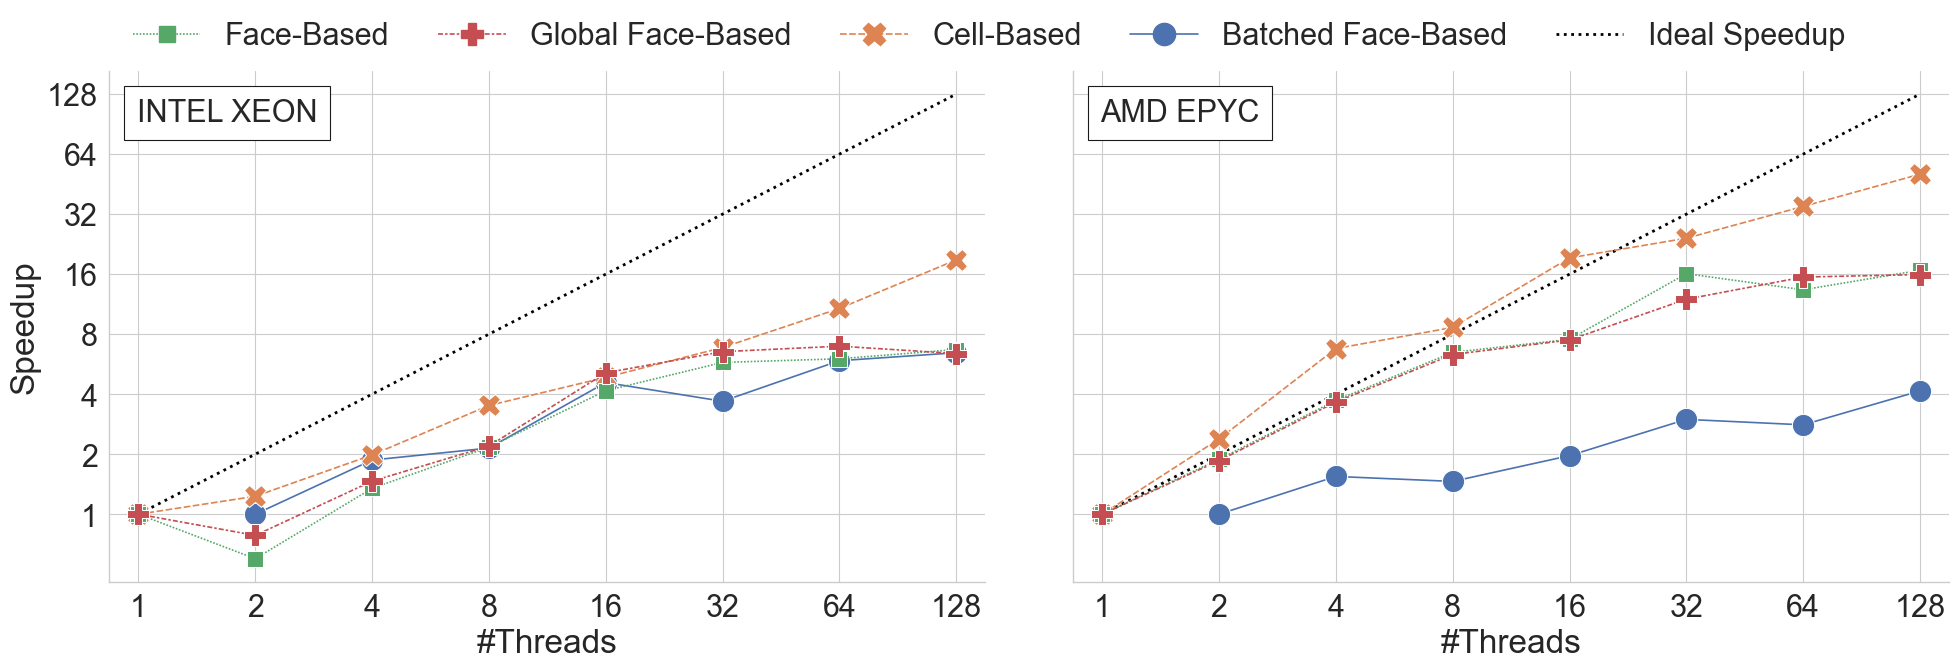

In [ ]:
# Polyester bandwidth speedup at the largest problem size
polyester_speedup_cells = int(polyester_source_df["cells"].max())
polyester_speedup_cells = 60**3
polyester_speedup_agg = (
    polyester_source_df[
        (polyester_source_df["variant"] == "Fused")
        & (polyester_source_df["cells"] == polyester_speedup_cells)
    ]
    .groupby(
        ["node", "strategy_display", "Threads", "cells"],
        as_index=False,
    )["bandwidth"]
    .mean()
)

# AMD serial runs are stored separately from the pinned-thread results.
polyester_amd_serial_df = pd.read_csv(
    "../variants/variations_serial.csv",
    skip_blank_lines=True,
)
polyester_amd_serial_df["cells"] = (
    polyester_amd_serial_df["case_long"].str.rsplit("-", n=1).str[-1].astype(int)
)
polyester_amd_serial_df = polyester_amd_serial_df.merge(
    polyester_nnz_df,
    on="cells",
    how="left",
    validate="many_to_one",
)
polyester_amd_serial_df["bandwidth"] = (
    polyester_amd_serial_df["nnz"]
    * 8
    / (polyester_amd_serial_df["time_mean_ms"] * 1_000_000)
)
polyester_amd_serial_df["strategy_display"] = polyester_amd_serial_df["strategy"].map(
    polyester_strategy_names
)
polyester_amd_serial_points = (
    polyester_amd_serial_df[
        (polyester_amd_serial_df["variant"] == "Fused")
        & (polyester_amd_serial_df["cells"] == polyester_speedup_cells)
    ]
    .groupby(["strategy_display", "cells"], as_index=False)["bandwidth"]
    .mean()
)
polyester_amd_serial_points["node"] = "H200"
polyester_amd_serial_points["Threads"] = 1

polyester_intel_serial_baseline = polyester_speedup_agg[
    (polyester_speedup_agg["node"] == "H100")
    & (polyester_speedup_agg["Threads"] == 1)
][["node", "strategy_display", "cells", "bandwidth"]]
polyester_amd_serial_baseline = polyester_amd_serial_points[
    ["node", "strategy_display", "cells", "bandwidth"]
]
# Batched Face-Based starts at two threads, so use that as its baseline.
polyester_batched_baseline = polyester_speedup_agg[
    (polyester_speedup_agg["strategy_display"] == "Batched Face-Based")
    & (polyester_speedup_agg["Threads"] == 2)
][["node", "strategy_display", "cells", "bandwidth"]]
polyester_speedup_baseline = pd.concat(
    [
        polyester_intel_serial_baseline,
        polyester_amd_serial_baseline,
        polyester_batched_baseline,
    ],
    ignore_index=True,
).rename(columns={"bandwidth": "baseline_bandwidth"})

polyester_speedup_data = pd.concat(
    [polyester_speedup_agg, polyester_amd_serial_points],
    ignore_index=True,
)
polyester_speedup_plot_df = polyester_speedup_data.merge(
    polyester_speedup_baseline,
    on=["node", "strategy_display", "cells"],
    how="inner",
    validate="many_to_one",
)
polyester_speedup_plot_df["speedup"] = (
    polyester_speedup_plot_df["bandwidth"]
    / polyester_speedup_plot_df["baseline_bandwidth"]
)
polyester_speedup_threads = sorted(
    polyester_speedup_plot_df["Threads"].unique()
)
polyester_speedup_thread_positions = {
    thread: position
    for position, thread in enumerate(polyester_speedup_threads)
}
polyester_speedup_plot_df["thread_position"] = polyester_speedup_plot_df[
    "Threads"
].map(polyester_speedup_thread_positions)

with sns.plotting_context("paper", font_scale=2.5):
    polyester_speedup_plot = sns.relplot(
        data=polyester_speedup_plot_df,
        x="thread_position",
        y="speedup",
        kind="line",
        col="node",
        col_order=["H100", "H200"],
        hue="strategy_display",
        style="strategy_display",
        hue_order=polyester_strategy_order,
        style_order=polyester_strategy_order,
        palette=polyester_palette,
        markers=True,
        markersize=16,
        errorbar=None,
        height=7,
        aspect=1.4,
    )
    polyester_speedup_plot.fig.set_size_inches(20, 7, forward=True)
    polyester_speedup_plot.set(
        yscale="log",
        xlabel="#Threads",
        ylabel="Speedup",
    )
    for axis in polyester_speedup_plot.axes.flat:
        axis.set_xticks(list(polyester_speedup_thread_positions.values()))
        axis.set_xticklabels([str(int(thread)) for thread in polyester_speedup_threads])
        axis.set_yticks(polyester_speedup_threads)
        axis.set_yticklabels([str(int(thread)) for thread in polyester_speedup_threads])
        axis.set_xlim(-0.25, len(polyester_speedup_threads) - 0.75)
        axis.plot(
            list(polyester_speedup_thread_positions.values()),
            polyester_speedup_threads,
            color="black",
            linestyle=":",
            linewidth=2,
            label="Ideal Speedup",
            zorder=1,
        )

    speedup_handles, speedup_labels = (
        polyester_speedup_plot.axes.flat[0].get_legend_handles_labels()
    )
    if polyester_speedup_plot._legend is not None:
        polyester_speedup_plot._legend.remove()
        polyester_speedup_plot._legend = None
    speedup_by_label = dict(zip(speedup_labels, speedup_handles))
    polyester_speedup_legend_order = [
        label for label in polyester_legend_order if label in speedup_by_label
    ] + ["Ideal Speedup"]
    polyester_speedup_ordered_handles = [
        speedup_by_label[label] for label in polyester_speedup_legend_order
    ]

    for axis, node_label in zip(
        polyester_speedup_plot.axes.flat,
        ["INTEL XEON", "AMD EPYC"],
    ):
        axis.add_artist(
            AnchoredText(
                node_label,
                loc="upper left",
                bbox_transform=axis.transAxes,
                frameon=True,
                prop={"size": plt.rcParams["legend.fontsize"]},
            )
        )
    polyester_speedup_plot.set_titles("")
    polyester_speedup_plot.fig.legend(
        polyester_speedup_ordered_handles,
        polyester_speedup_legend_order,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.98),
        ncol=5,
        columnspacing=1.6,
        handlelength=2.2,
        frameon=False,
    )
    polyester_speedup_plot.fig.subplots_adjust(
        left=0.06,
        right=0.98,
        bottom=0.14,
        top=0.87,
        wspace=0.1,
    )

polyester_speedup_plot.fig.savefig("cpu-bandwidth-speedup-polyester.svg")


labels: ['Fused Cell-Based (NeoN)', 'Cell-Based (NeoN)', 'Global Face-Based (NeoN)', 'Face-Based (JuNe)', 'Cell-Based (JuNe)', 'Global Face-Based (JuNe)', 'Fused Face-Based (NeoN)', 'Face-Based (NeoN)']


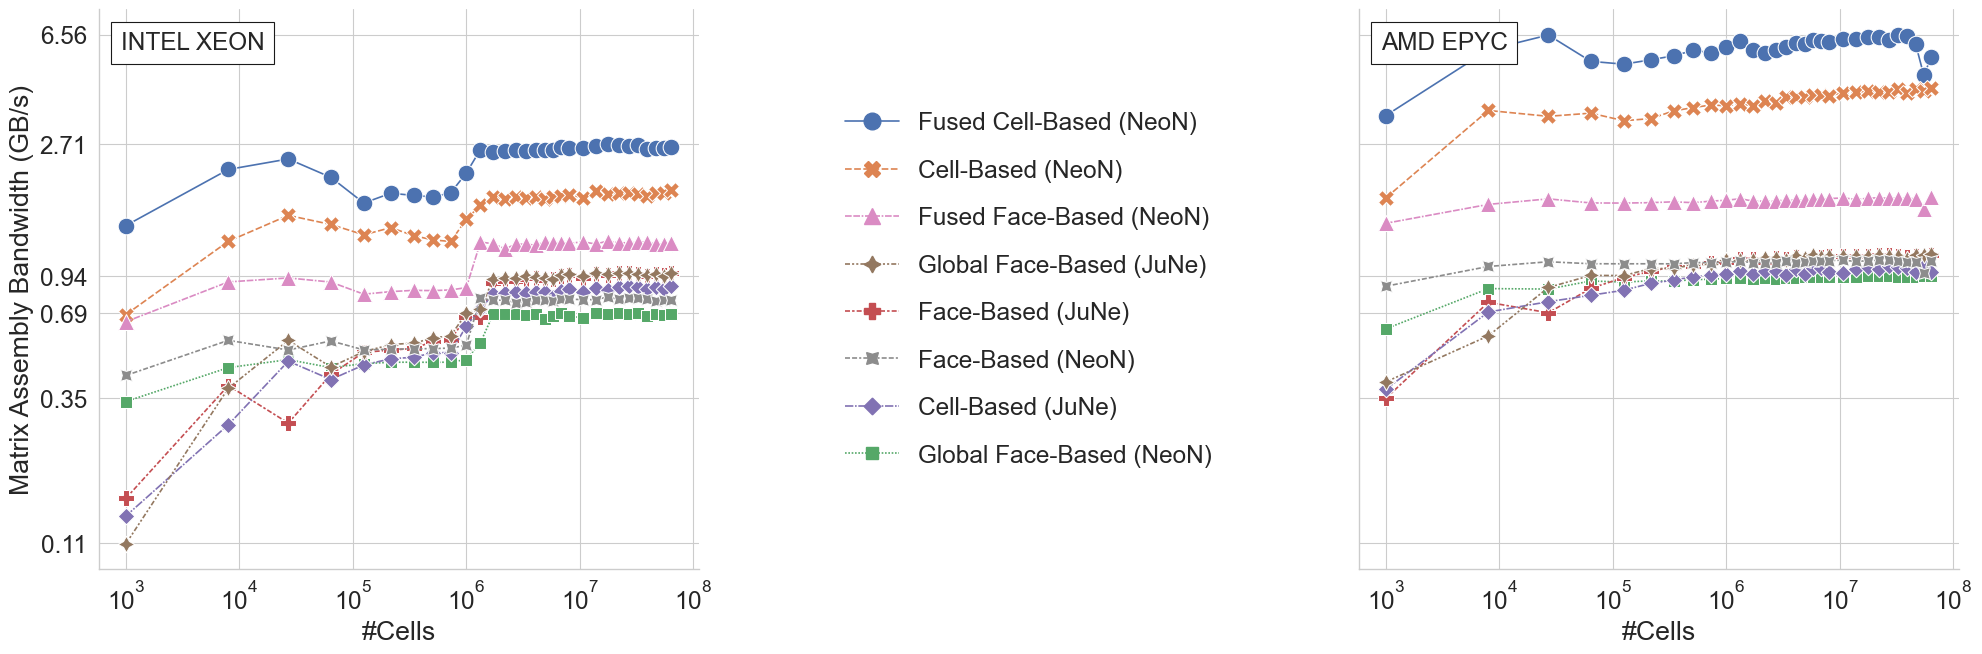

In [76]:
# TEST HERE
# ----
# 
#------------------------
# Plot
# ----------------------------
sns.set_theme(rc={'figure.figsize':(20, 12)})
sns.set_style("whitegrid")
sns.color_palette("deep", 8)

bandwidth_source_df = pd.read_csv("../results/NEON-CPU.csv")
bandwidth_source_df["strategy_full"] = (
    bandwidth_source_df["strategy"]
    + " ("
    + bandwidth_source_df["julia_or_neon"]
    + ")"
)
bandwidth_source_df["ms_mean"] = bandwidth_source_df["time_us"] / 1e3
bandwidth_source_df["bandwidth"] = bandwidth_source_df["nnz"] * 24 / (bandwidth_source_df["ms_mean"] * 1000000)
bandwidth_plot_df = bandwidth_source_df[bandwidth_source_df["threads"] == 1].copy()
nodes = sorted(bandwidth_plot_df["node"].unique())

# for ax, node in zip(axes, nodes):
with sns.plotting_context("paper", font_scale=2):
    p = sns.relplot(
        data=bandwidth_plot_df,
        x="cells",
        y="bandwidth",
        kind="line",
        col="node",
        col_order=["gpu-nvidia-h100", "gpu-nvidia-h200"],
        hue="strategy_full",
        style="strategy_full",
        err_style=None,
        markersize=12,
        height=7,
        markers=True
    )

    # Ideal scaling
    threads = sorted(
        bandwidth_source_df["threads"].unique()
    )

    p.set(
        yscale="log",
        xscale="log",
        xlabel="#Cells",
        ylabel="Matrix Assembly Bandwidth (GB/s)",
    )
    ytick_strategies = [
        "Fused Cell-Based (NeoN)",
        "Global Face-Based (NeoN)",
    ]
    test_here_line_bandwidth = bandwidth_plot_df.groupby(
        ["node", "strategy_full", "cells"],
        as_index=False,
    )["bandwidth"].mean()
    peak_yticks = test_here_line_bandwidth[
        test_here_line_bandwidth["strategy_full"].isin(ytick_strategies)
    ].groupby(["node", "strategy_full"])["bandwidth"].max().to_numpy()
    min_yticks = test_here_line_bandwidth.groupby("node")["bandwidth"].min().to_numpy()
    extra_yticks = np.concatenate([peak_yticks, min_yticks])
    for ax in p.axes.flat:
        ymin, ymax = ax.get_ylim()
        custom_yticks = [round(float(tick), 3) for tick in extra_yticks if ymin <= tick <= ymax]
        ytick_values = sorted(set(custom_yticks))
        ax.set_yticks(ytick_values)
        ax.set_yticklabels([
            f"{tick:.2f}"
            for tick in ytick_values
        ])
    p.axes.flat[0].tick_params(axis="y", which="both", labelleft=True)
    p.axes.flat[1].tick_params(axis="y", which="both", labelleft=False)

    # Match the earlier AMD plot: sort by each strategy's final AMD value.
    desired_order = (
        test_here_line_bandwidth[
            test_here_line_bandwidth["node"] == "gpu-nvidia-h200"
        ].sort_values("cells")
        .groupby("strategy_full")["bandwidth"]
        .last()
        .sort_values(ascending=False)
        .index.tolist()
    )
    handles, labels = p.axes.flat[0].get_legend_handles_labels()
    if p._legend is not None:
        p._legend.remove()
        p._legend = None
    print(f"labels: {labels}")
    by_label = dict(zip(labels, handles))

    test_here_ordered_labels = [label for label in desired_order if label in by_label]
    test_here_ordered_handles = [by_label[label] for label in test_here_ordered_labels]
    
    at = AnchoredText(
        "INTEL XEON",
        loc="upper left",
        # bbox_to_anchor=(0.975, 0.92),
        bbox_transform=p.axes.flat[0].transAxes,
        frameon=True,
        prop={"size": plt.rcParams["legend.fontsize"]},
    )
    p.axes.flat[0].add_artist(at)  
    at = AnchoredText(
        "AMD EPYC",
        loc="upper left",
        # bbox_to_anchor=(0.975, 0.92),
        bbox_transform=p.axes.flat[1].transAxes,
        frameon=True,
        prop={"size": plt.rcParams["legend.fontsize"]},
    )
    p.axes.flat[1].add_artist(at)    
    p.set_titles("")

    # Reserve a center column for the shared legend.
    p.fig.set_size_inches(20, 7, forward=True)
    p.axes.flat[0].set_position([0.055, 0.14, 0.34, 0.80])
    p.axes.flat[1].set_position([0.645, 0.14, 0.34, 0.80])
    p.fig.legend(
        test_here_ordered_handles,
        test_here_ordered_labels,
        loc="center",
        bbox_to_anchor=(0.52, 0.54),
        ncol=1,
        labelspacing=1.0,
        handlelength=2.2,
        # title="Fused Strategy",
        frameon=False,
    )

plt.savefig("cpu-bandwidth-1.svg")


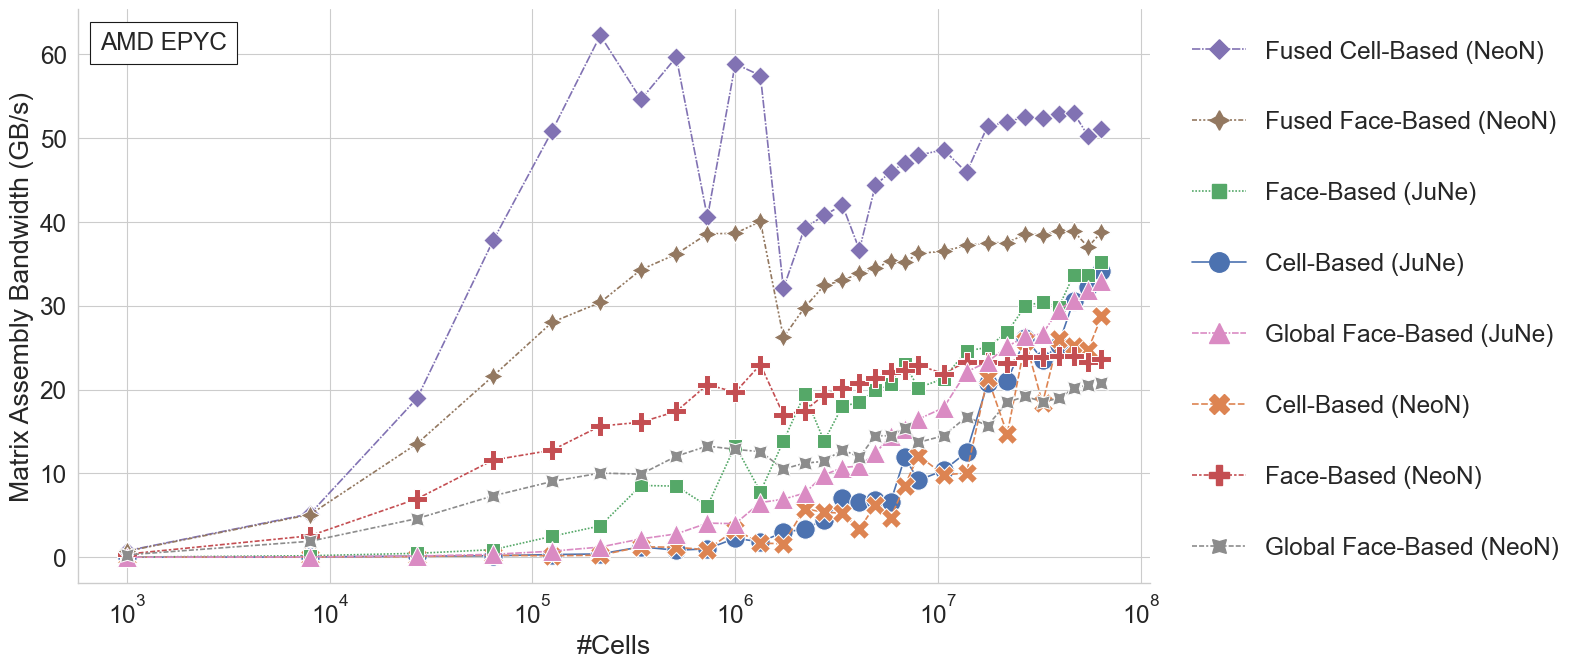

In [61]:
# AMD bandwidth at 128 threads
sns.set_style("whitegrid")
bandwidth_figure_size = (16, 7)
bandwidth_plot_bounds = {
    "left": 0.06,
    "right": 0.73,
    "bottom": 0.14,
    "top": 0.96,
}
bandwidth_legend_x = 0.75
bandwidth_legend_y_limits = (0.90, 0.19)

amd_bandwidth_source_df = pd.read_csv("../results/NEON-CPU.csv")
amd_bandwidth_source_df["strategy_full"] = (
    amd_bandwidth_source_df["strategy"]
    + " ("
    + amd_bandwidth_source_df["julia_or_neon"]
    + ")"
)
amd_bandwidth_source_df["ms_mean"] = amd_bandwidth_source_df["time_us"] / 1e3
amd_bandwidth_source_df["bandwidth"] = (
    amd_bandwidth_source_df["nnz"]
    * 24
    / (amd_bandwidth_source_df["ms_mean"] * 1_000_000)
)
amd_bandwidth_plot_df = amd_bandwidth_source_df[
    (amd_bandwidth_source_df["threads"] == 128)
    & (amd_bandwidth_source_df["node"] == "gpu-nvidia-h200")
].copy()
bandwidth_strategy_order = sorted(amd_bandwidth_plot_df["strategy_full"].unique())
bandwidth_palette = dict(
    zip(
        bandwidth_strategy_order,
        sns.color_palette("deep", n_colors=len(bandwidth_strategy_order)),
    )
)

with sns.plotting_context("paper", font_scale=2):
    amd_plot = sns.relplot(
        data=amd_bandwidth_plot_df,
        x="cells",
        y="bandwidth",
        kind="line",
        hue="strategy_full",
        style="strategy_full",
        hue_order=bandwidth_strategy_order,
        style_order=bandwidth_strategy_order,
        palette=bandwidth_palette,
        err_style=None,
        markersize=14,
        markers=True,
        height=bandwidth_figure_size[1],
        aspect=bandwidth_figure_size[0] / bandwidth_figure_size[1],
    )
    amd_plot.fig.set_size_inches(*bandwidth_figure_size, forward=True)
    amd_plot.set(
        xscale="log",
        xlabel="#Cells",
        ylabel="Matrix Assembly Bandwidth (GB/s)",
    )
    ytick_strategies = [
        "Fused Cell-Based (NeoN)",
        "Global Face-Based (NeoN)",
    ]
    amd_line_bandwidth = amd_bandwidth_plot_df.groupby(
        ["strategy_full", "cells"],
        as_index=False,
    )["bandwidth"].mean()
    peak_yticks = amd_line_bandwidth[
        amd_line_bandwidth["strategy_full"].isin(ytick_strategies)
    ].groupby("strategy_full")["bandwidth"].max().to_numpy()
    min_yticks = np.array([amd_line_bandwidth["bandwidth"].min()])
    extra_yticks = np.concatenate([peak_yticks, min_yticks])
    # for ax in amd_plot.axes.flat:
    #     ymin, ymax = ax.get_ylim()
    #     custom_yticks = [round(float(tick), 3) for tick in extra_yticks if ymin <= tick <= ymax]
    #     ytick_values = sorted(set(custom_yticks))
    #     ax.set_yticks(ytick_values)
    #     ax.set_yticklabels([
    #         f"{tick:.2f}"
    #         for tick in ytick_values
    #     ])
    amd_plot.axes.flat[0].tick_params(axis="y", which="both", labelleft=True)

    legend_order = (
        amd_line_bandwidth.sort_values("cells")
        .groupby("strategy_full")["bandwidth"]
        .last()
        .sort_values(ascending=False)
        .index.tolist()
    )
    handles, labels = amd_plot.axes.flat[0].get_legend_handles_labels()
    if amd_plot._legend is not None:
        amd_plot._legend.remove()
        amd_plot._legend = None
    by_label = dict(zip(labels, handles))

    ordered_labels = [label for label in legend_order if label in by_label]
    ordered_handles = [by_label[label] for label in ordered_labels]
    
    at = AnchoredText(
        "AMD EPYC",
        loc="upper left",
        bbox_transform=amd_plot.axes.flat[0].transAxes,
        frameon=True,
        prop={"size": plt.rcParams["legend.fontsize"]},
    )
    amd_plot.axes.flat[0].add_artist(at)
    amd_plot.set_titles("")

    legend_y_positions = np.linspace(
        *bandwidth_legend_y_limits,
        len(ordered_labels),
    )
    for handle, label, legend_y in zip(
        ordered_handles,
        ordered_labels,
        legend_y_positions,
    ):
        amd_plot.fig.legend(
            [handle],
            [label],
            loc="center left",
            bbox_to_anchor=(bandwidth_legend_x, float(legend_y)),
            handlelength=2.2,
            borderaxespad=0,
            frameon=False,
        )
    amd_plot.fig.subplots_adjust(**bandwidth_plot_bounds)

amd_plot.fig.savefig("cpu-bandwidth-128-amd.svg")


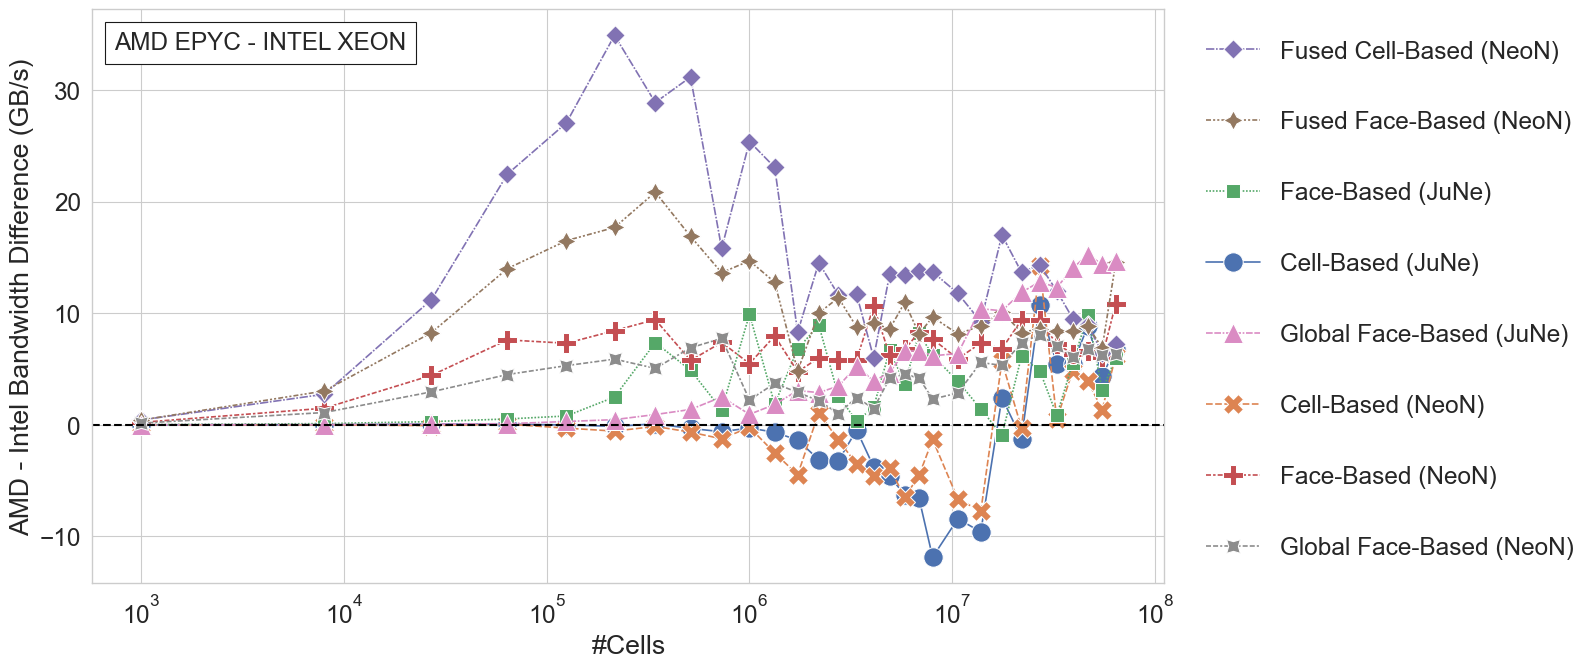

In [60]:
# AMD - Intel bandwidth difference at 128 threads
mean_bandwidth_128 = (
    amd_bandwidth_source_df[amd_bandwidth_source_df["threads"] == 128]
    .groupby(["node", "strategy_full", "cells"], as_index=False)["bandwidth"]
    .mean()
)
amd_bandwidth_128 = (
    mean_bandwidth_128[mean_bandwidth_128["node"] == "gpu-nvidia-h200"]
    .drop(columns="node")
    .rename(columns={"bandwidth": "bandwidth_amd"})
)
intel_bandwidth_128 = (
    mean_bandwidth_128[mean_bandwidth_128["node"] == "gpu-nvidia-h100"]
    .drop(columns="node")
    .rename(columns={"bandwidth": "bandwidth_intel"})
)
bandwidth_difference_df = amd_bandwidth_128.merge(
    intel_bandwidth_128,
    on=["strategy_full", "cells"],
    how="inner",
)
bandwidth_difference_df["bandwidth_difference"] = (
    bandwidth_difference_df["bandwidth_amd"]
    - bandwidth_difference_df["bandwidth_intel"]
)
difference_available_strategies = set(bandwidth_difference_df["strategy_full"].unique())
difference_strategy_order = [
    strategy
    for strategy in bandwidth_strategy_order
    if strategy in difference_available_strategies
]

with sns.plotting_context("paper", font_scale=2):
    difference_fig, difference_ax = plt.subplots(figsize=bandwidth_figure_size)
    sns.lineplot(
        data=bandwidth_difference_df,
        x="cells",
        y="bandwidth_difference",
        hue="strategy_full",
        style="strategy_full",
        hue_order=difference_strategy_order,
        style_order=difference_strategy_order,
        palette=bandwidth_palette,
        err_style=None,
        markers=True,
        markersize=14,
        ax=difference_ax,
    )
    difference_ax.set(
        xscale="log",
        xlabel="#Cells",
        ylabel="AMD - Intel Bandwidth Difference (GB/s)",
    )
    difference_ax.axhline(0, color="black", linestyle="--", linewidth=1.5)
    difference_legend_order = [
        strategy
        for strategy in legend_order
        if strategy in difference_available_strategies
    ]
    difference_handles, difference_labels = difference_ax.get_legend_handles_labels()
    difference_legend = difference_ax.get_legend()
    if difference_legend is not None:
        difference_legend.remove()
    difference_by_label = dict(zip(difference_labels, difference_handles))
    difference_ordered_labels = [
        label for label in difference_legend_order if label in difference_by_label
    ]
    difference_ordered_handles = [
        difference_by_label[label] for label in difference_ordered_labels
    ]

    at = AnchoredText(
        "AMD EPYC - INTEL XEON",
        loc="upper left",
        bbox_transform=difference_ax.transAxes,
        frameon=True,
        prop={"size": plt.rcParams["legend.fontsize"]},
    )
    difference_ax.add_artist(at)

    difference_legend_y_positions = np.linspace(
        *bandwidth_legend_y_limits,
        len(difference_ordered_labels),
    )
    for handle, label, legend_y in zip(
        difference_ordered_handles,
        difference_ordered_labels,
        difference_legend_y_positions,
    ):
        difference_fig.legend(
            [handle],
            [label],
            loc="center left",
            bbox_to_anchor=(bandwidth_legend_x, float(legend_y)),
            handlelength=2.2,
            borderaxespad=0,
            frameon=False,
        )
    difference_fig.subplots_adjust(**bandwidth_plot_bounds)
    difference_fig.savefig("cpu-bandwidth-difference-amd-intel-128.svg")


In [ ]:
plot_df.to_csv("plotdt.csv")


In [ ]:
# ----------------------------
# Load
# ----------------------------
df = pd.read_csv("../results/NEON-GPU.csv")

# Full strategy name
df["strategy_full"] = (
    df["strategy"]
    + " ("
    + df["julia_or_neon"]
    + ")"
)

# ----------------------------
# Convert time -> milliseconds
# ----------------------------
df["ms_mean"] = df["time_us"] / 1e3

# Effective bandwidth [GB/s]
# nnz * 24 bytes / runtime
df["bandwidth"] = df["nnz"] * 24  / (df["ms_mean"] * 1000000) 

# Equivalent:
# df["bandwidth"] = df["nnz"] * 24 / (df["time_us"] / 1e6)

# ----------------------------
# Aggregate repetitions
# ----------------------------
agg = (
    df.groupby(
        [
            "strategy_full",
            "threads",
            "node",
            "executor",
        ],
        as_index=False,
    )
    .agg(
        bandwidth=("bandwidth", "median")
    )
)



In [32]:

# ----------------------------
# Plot
# ----------------------------
sns.set_theme(rc={'figure.figsize':(20, 12)})
sns.set_style("whitegrid")
sns.color_palette("deep", 8)

nodes = sorted(plot_df["node"].unique())

# for ax, node in zip(axes, nodes):
with sns.plotting_context("paper", font_scale=1.7):
    p = sns.relplot(
        data=df[(df["threads"]==1) ],
        x="cells",
        y="bandwidth",
        kind="line",
        col="node",
        col_order=["gpu-nvidia-h100", "gpu-nvidia-h200"],
        hue="strategy_full",
        style="strategy_full",
        err_style=None,
        markersize=10,
        markers=True
    )

    # Ideal scaling
    threads = sorted(
        subset["threads"].unique()
    )

    p.set(
        # yscale="log",
        xscale="log",
        xlabel="#Threads",
        ylabel="Matrix Assembly Bandwidth (GB/s)",
    )

    desired_order = [
        "Cell-Based (NeoN)",
        "Cell-Based (JuNe)",
        "Global Face-Based (NeoN)",
        "Global Face-Based (JuNe)",
        "Face-Based (NeoN)",
        "Face-Based (JuNe)",
        "Fused Face-Based (NeoN)",
        "Fused Cell-Based (NeoN)"
    ]
    handles, labels = p.axes.flat[0].get_legend_handles_labels()
    if p._legend is not None:
        p._legend.remove()
        p._legend = None
    print(f"labels: {labels}")
    by_label = dict(zip(labels, handles))

    ordered_labels = [label for label in desired_order if label in by_label]
    ordered_handles = [by_label[label] for label in ordered_labels]
    
    at = AnchoredText(
        "INTEL XEON",
        loc="upper left",
        # bbox_to_anchor=(0.975, 0.92),
        bbox_transform=p.axes.flat[0].transAxes,
        frameon=True,
        prop={"size": plt.rcParams["legend.fontsize"]},
    )
    p.axes.flat[0].add_artist(at)  
    at = AnchoredText(
        "AMD EPYC",
        loc="upper left",
        # bbox_to_anchor=(0.975, 0.92),
        bbox_transform=p.axes.flat[1].transAxes,
        frameon=True,
        prop={"size": plt.rcParams["legend.fontsize"]},
    )
    p.axes.flat[1].add_artist(at)    
    p.set_titles("")

    p.fig.legend(
        ordered_handles,
        ordered_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.03),
        ncol=4,
        # title="Fused Strategy",
        frameon=False,
    )
    p.fig.subplots_adjust(
        left=0.07,
        right=0.98,
        # bottom=0.18,
        top=0.78,
        # wspace=0.1,
    )

plt.savefig("cpu-bandwidth-1.svg")


NameError: name 'plot_df' is not defined